<a href="https://colab.research.google.com/github/Kellia855/Formative3-Group31/blob/main/Formative3_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

This notebook contains our group assignment on probability distributions, Bayesian probability and gradient descent.  
The goal is to apply mathematical concepts to real datasets and demonstrate both manual and coded solutions.

- **Part 1** uses the Expectation–Maximization (EM) algorithm to model a mixture of Gaussian distributions from height data. We show how parameters are updated step by step and why splitting at the global mean is misleading.  
- **Part 2** applies Bayes’ Theorem to sentiment analysis with IMDb reviews. By selecting positive and negative keywords, we compute posterior probabilities and show how Bayesian reasoning can classify text.  
- **Part 3** involves manual gradient descent calculations for linear regression.

- **Part 4** implements gradient descent in Python with visualizations.

Together, these parts highlight the importance of probabilistic modeling, Bayesian inference, and optimization in data science. The notebook also demonstrates teamwork, modular coding and clear communication.


## Part 1: Expectation–Maximization (EM) Algorithm

In this section we apply the EM algorithm to a dataset of heights, treating it as a mixture of two Gaussian distributions.  
The goal is to iteratively estimate the parameters (means, variances, and mixing coefficients) and compute posterior probabilities for classification.  
We also demonstrate why splitting at the global mean is misleading compared to probabilistic assignments.


### Step 1: Import libraries
We start by importing the necessary Python libraries for data handling, math and visualization.

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt


### Step 2: Load the dataset
We load the Galton Families dataset and focus on the `childHeight` column for our EM algorithm.


In [2]:
df = pd.read_csv("GaltonFamilies.csv")
data = df['childHeight'].values
df.head()


,rownames,family,father,mother,midparentHeight,children,childNum,gender,childHeight
0,1,001,78.5,67.0,75.43,4,1,male,73.2
1,2,001,78.5,67.0,75.43,4,2,female,69.2
2,3,001,78.5,67.0,75.43,4,3,female,69.0
3,4,001,78.5,67.0,75.43,4,4,female,69.0
4,5,002,75.5,66.5,73.66,4,1,male,73.5


### Step 3: Visualize the data
We plot a histogram of child heights to see the distribution before applying EM.


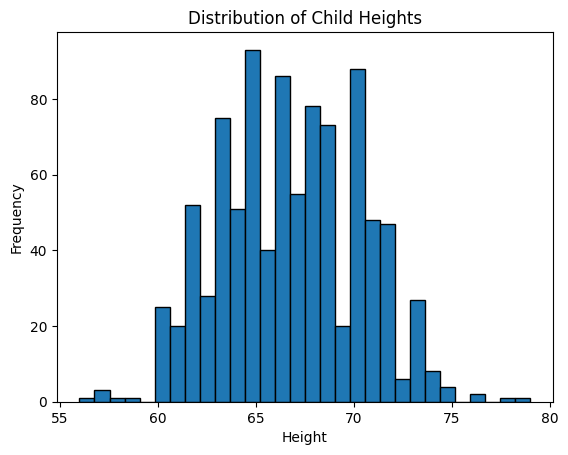

In [3]:
plt.hist(data, bins=30, edgecolor='black')
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.title("Distribution of Child Heights")
plt.show()


### Step 4: Initialize parameters
We randomly choose initial means and set starting values for variances and mixing coefficients.


In [4]:
mu1, mu2 = np.random.choice(data, 2)
sigma1, sigma2 = np.std(data), np.std(data)
pi1, pi2 = 0.5, 0.5


### Step 5: Define EM functions
We implement the E-step, M-step and log-likelihood functions for the EM algorithm.


In [5]:
def e_step(data, mu1, mu2, sigma1, sigma2, pi1, pi2):
    r1 = pi1 * norm.pdf(data, mu1, sigma1)
    r2 = pi2 * norm.pdf(data, mu2, sigma2)
    total = r1 + r2
    return r1/total, r2/total

def m_step(data, r1, r2):
    mu1 = np.sum(r1 * data) / np.sum(r1)
    mu2 = np.sum(r2 * data) / np.sum(r2)
    sigma1 = np.sqrt(np.sum(r1 * (data - mu1)**2) / np.sum(r1))
    sigma2 = np.sqrt(np.sum(r2 * (data - mu2)**2) / np.sum(r2))
    pi1 = np.mean(r1)
    pi2 = np.mean(r2)
    return mu1, mu2, sigma1, sigma2, pi1, pi2

def log_likelihood(data, mu1, mu2, sigma1, sigma2, pi1, pi2):
    return np.sum(np.log(pi1*norm.pdf(data, mu1, sigma1) + pi2*norm.pdf(data, mu2, sigma2)))


### Step 6: Run EM loop
We run the EM algorithm for a few iterations and print the tracking table with parameter updates.


In [6]:
print("Iteration | mu1 | mu2 | sigma1 | sigma2 | pi1 | pi2 | Log-Likelihood")
for iteration in range(3):  # show first 3 iterations
    r1, r2 = e_step(data, mu1, mu2, sigma1, sigma2, pi1, pi2)
    mu1, mu2, sigma1, sigma2, pi1, pi2 = m_step(data, r1, r2)
    ll = log_likelihood(data, mu1, mu2, sigma1, sigma2, pi1, pi2)
    print(f"{iteration:9d} | {mu1:.2f} | {mu2:.2f} | {sigma1:.2f} | {sigma2:.2f} | {pi1:.2f} | {pi2:.2f} | {ll:.2f}")


Iteration | mu1 | mu2 | sigma1 | sigma2 | pi1 | pi2 | Log-Likelihood
        0 | 64.49 | 69.25 | 2.63 | 2.72 | 0.53 | 0.47 | -2503.23
        1 | 64.43 | 69.31 | 2.57 | 2.68 | 0.53 | 0.47 | -2502.19
        2 | 64.39 | 69.36 | 2.52 | 2.64 | 0.53 | 0.47 | -2501.31


### Step 7: Demo classification
We test the model with a random height and output posterior probabilities for each group.


In [7]:
test_height = 72.0
prob_child = pi1 * norm.pdf(test_height, mu1, sigma1)
prob_father = pi2 * norm.pdf(test_height, mu2, sigma2)
total = prob_child + prob_father

print(f"Posterior probabilities for test height = {test_height}")
print("P(Child):", prob_child/total)
print("P(Father):", prob_father/total)


Posterior probabilities for test height = 72.0
P(Child): 0.019454066625855665
P(Father): 0.9805459333741444


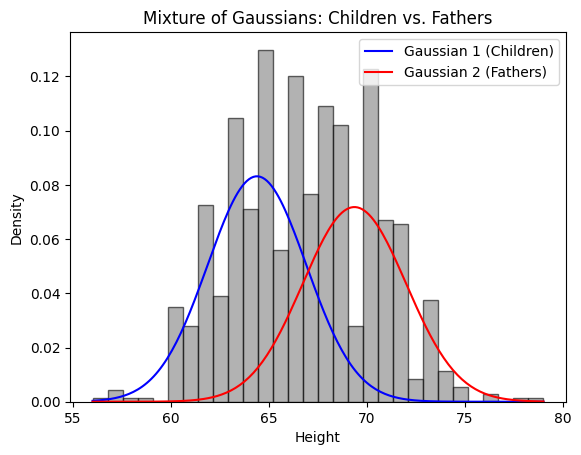

In [8]:
plt.hist(data, bins=30, density=True, alpha=0.6, color='gray', edgecolor='black')

x = np.linspace(min(data), max(data), 200)
curve1 = pi1 * norm.pdf(x, mu1, sigma1)
curve2 = pi2 * norm.pdf(x, mu2, sigma2)

plt.plot(x, curve1, label="Gaussian 1 (Children)", color='blue')
plt.plot(x, curve2, label="Gaussian 2 (Fathers)", color='red')
plt.xlabel("Height")
plt.ylabel("Density")
plt.title("Mixture of Gaussians: Children vs. Fathers")
plt.legend()
plt.show()


### Step 8: Why not split at the global mean?
Simply drawing a line at the dataset’s overall mean height to separate two groups is misleading.  
The reason is that the two Gaussian distributions (Children vs. Fathers) overlap, so many individuals fall near the mean and would be misclassified by a hard cut.  
The EM algorithm avoids this problem by assigning probabilistic membership to each group, giving a more accurate classification that reflects the overlap in the data.


## Part 2: Bayesian Probability

Here we use Bayes’ Theorem to classify IMDb reviews based on selected keywords.  
By calculating priors, likelihoods and posterior probabilities, we show how Bayesian reasoning can be applied to text sentiment analysis.  
This highlights the role of probability in decision‑making when information is uncertain.


### Step 1: Overview and keywords

We choose words with strong positive or negative sentiment and compare how often they appear in positive vs negative reviews.  
This section focuses on the posterior probability of a review being positive given a keyword.

| Sentiment we expect | Keywords |
|---|---|
| Positive | wonderful, excellent, brilliant |
| Negative | terrible, awful, boring |


### Step 2: Define helper functions

We define functions to load reviews, tokenize text, count keyword occurrences, and compute Bayes probabilities.  
Each helper function uses only Python’s standard library.


In [1]:
import csv
from IPython.display import Markdown, display

def load_reviews(filepath):
    """Read the IMDB CSV -> list of (review_text, sentiment) tuples."""
    reviews = []
    with open(filepath, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            reviews.append((row["review"], row["sentiment"]))
    return reviews

def tokenize(text):
    """Lowercase and split into whole words."""
    lowered = text.lower()
    cleaned = "".join(ch if ch.isalpha() else " " for ch in lowered)
    return cleaned.split()

def compute_counts(reviews, keywords):
    """Count total reviews, positive reviews, and keyword frequencies."""
    total = 0
    positive_total = 0
    keyword_total = {kw: 0 for kw in keywords}
    keyword_and_positive = {kw: 0 for kw in keywords}

    for text, sentiment in reviews:
        total += 1
        is_positive = sentiment == "positive"
        if is_positive:
            positive_total += 1

        tokens = set(tokenize(text))
        for kw in keywords:
            if kw in tokens:
                keyword_total[kw] += 1
                if is_positive:
                    keyword_and_positive[kw] += 1

    return {
        "total": total,
        "positive_total": positive_total,
        "keyword_total": keyword_total,
        "keyword_and_positive": keyword_and_positive,
    }

def bayes_positive_given_keyword(counts, keyword):
    """Compute P(Positive | keyword) using Bayes' Theorem."""
    total = counts["total"]
    positive_total = counts["positive_total"]
    kw_total = counts["keyword_total"][keyword]
    kw_and_pos = counts["keyword_and_positive"][keyword]

    if kw_total == 0:
        raise ValueError(f"'{keyword}' never appears; P(keyword) = 0.")

    prior = positive_total / total
    likelihood = kw_and_pos / positive_total
    marginal = kw_total / total
    posterior = (likelihood * prior) / marginal

    return {
        "prior": prior,
        "likelihood": likelihood,
        "marginal": marginal,
        "posterior": posterior,
        "direct_ratio": kw_and_pos / kw_total,
    }

def format_keyword_markdown(keyword, p):
    """Format the results as a Markdown table."""
    return (
        f"### Keyword: `{keyword}`\n\n"
        f"| Quantity | Symbol | Value |\n"
        f"|---|---|---|\n"
        f"| Prior | P(Positive) | {p['prior']:.4f} |\n"
        f"| Likelihood | P('{keyword}' \\| Positive) | {p['likelihood']:.4f} |\n"
        f"| Marginal | P('{keyword}') | {p['marginal']:.4f} |\n"
        f"| **Posterior** | **P(Positive \\| '{keyword}')** | **{p['posterior']:.4f}** |\n"
    )

def format_summary_table(results):
    """Create a summary table sorted by posterior."""
    lines = [
        "| Keyword | Prior | Likelihood | Marginal | Posterior |",
        "|---|---|---|---|---|",
    ]
    for kw, p in sorted(results.items(), key=lambda kv: -kv[1]["posterior"]):
        lines.append(
            f"| {kw} | {p['prior']:.4f} | {p['likelihood']:.4f} "
            f"| {p['marginal']:.4f} | {p['posterior']:.4f} |"
        )
    return "\n".join(lines)


### Step 3: Load the dataset

We locate the IMDb review file and load it. If the file is not found, the notebook raises a clear error.


In [2]:
from pathlib import Path

DATA_PATH = Path("IMDB Dataset.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path.cwd() / "IMDB Dataset.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"CSV file not found. Expected it in the notebook folder or current working directory: {DATA_PATH}"
    )

KEYWORDS = ["wonderful", "excellent", "brilliant",
            "terrible", "awful", "boring"]

reviews = load_reviews(DATA_PATH)
counts = compute_counts(reviews, KEYWORDS)

print(f"Loaded {counts['total']} reviews "
      f"({counts['positive_total']} positive, "
      f"{counts['total'] - counts['positive_total']} negative)")
print(f"Using CSV path: {DATA_PATH}")


Loaded 50000 reviews (25000 positive, 25000 negative)
Using CSV path: IMDB Dataset.csv


### Step 4: Compute Bayes' Theorem for each keyword

We compute posterior probabilities for each chosen keyword and display the results as Markdown tables.  
A verification check confirms the algebraic simplification for each keyword.


In [3]:
results = {}
for kw in KEYWORDS:
    probs = bayes_positive_given_keyword(counts, kw)
    results[kw] = probs
    display(Markdown(format_keyword_markdown(kw, probs)))
    ok = abs(probs["posterior"] - probs["direct_ratio"]) < 1e-9
    display(Markdown(
        f"*Verification (posterior == positive-with-word / all-with-word): **{ok}***"
    ))


### Keyword: `wonderful`

| Quantity | Symbol | Value |
|---|---|---|
| Prior | P(Positive) | 0.5000 |
| Likelihood | P('wonderful' \| Positive) | 0.0903 |
| Marginal | P('wonderful') | 0.0556 |
| **Posterior** | **P(Positive \| 'wonderful')** | **0.8122** |


*Verification (posterior == positive-with-word / all-with-word): **True***

### Keyword: `excellent`

| Quantity | Symbol | Value |
|---|---|---|
| Prior | P(Positive) | 0.5000 |
| Likelihood | P('excellent' \| Positive) | 0.1147 |
| Marginal | P('excellent') | 0.0710 |
| **Posterior** | **P(Positive \| 'excellent')** | **0.8074** |


*Verification (posterior == positive-with-word / all-with-word): **True***

### Keyword: `brilliant`

| Quantity | Symbol | Value |
|---|---|---|
| Prior | P(Positive) | 0.5000 |
| Likelihood | P('brilliant' \| Positive) | 0.0635 |
| Marginal | P('brilliant') | 0.0418 |
| **Posterior** | **P(Positive \| 'brilliant')** | **0.7601** |


...

*Verification (posterior == positive-with-word / all-with-word): **True***

### Keyword: `awful`

| Quantity | Symbol | Value |
|---|---|---|
| Prior | P(Positive) | 0.5000 |
| Likelihood | P('awful' \| Positive) | 0.0114 |
| Marginal | P('awful') | 0.0577 |
| **Posterior** | **P(Positive \| 'awful')** | **0.0985** |


*Verification (posterior == positive-with-word / all-with-word): **True***

### Keyword: `boring`

| Quantity | Symbol | Value |
|---|---|---|
| Prior | P(Positive) | 0.5000 |
| Likelihood | P('boring' \| Positive) | 0.0237 |
| Marginal | P('boring') | 0.0610 |
| **Posterior** | **P(Positive \| 'boring')** | **0.1940** |


*Verification (posterior == positive-with-word / all-with-word): **True***

### Step 5: Summary

We summarize the posterior probabilities for all keywords, sorted from most positive to least positive.


In [4]:
display(Markdown("## Summary — all keywords (highest = most positive)\n\n"
                 + format_summary_table(results)))


## Summary — all keywords (highest = most positive)

| Keyword | Prior | Likelihood | Marginal | Posterior |
|---|---|---|---|---|
| wonderful | 0.5000 | 0.0903 | 0.0556 | 0.8122 |
| excellent | 0.5000 | 0.1147 | 0.0710 | 0.8074 |
| brilliant | 0.5000 | 0.0635 | 0.0418 | 0.7601 |
| boring | 0.5000 | 0.0237 | 0.0610 | 0.1940 |
| terrible | 0.5000 | 0.0153 | 0.0540 | 0.1418 |
| awful | 0.5000 | 0.0114 | 0.0577 | 0.0985 |

### Step 6: Visualization

This chart is for presentation only; the Bayes calculation above uses no extra libraries.


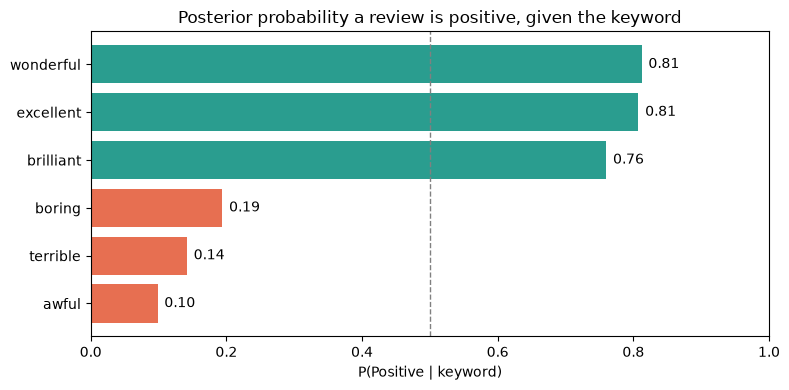

In [5]:
import matplotlib.pyplot as plt

order = sorted(results, key=lambda k: results[k]["posterior"])
posteriors = [results[k]["posterior"] for k in order]
colors = ["#2a9d8f" if p >= 0.5 else "#e76f51" for p in posteriors]

plt.figure(figsize=(8, 4))
plt.barh(order, posteriors, color=colors)
plt.axvline(0.5, linestyle="--", color="gray", linewidth=1)
for i, p in enumerate(posteriors):
    plt.text(p + 0.01, i, f"{p:.2f}", va="center")
plt.xlim(0, 1)
plt.xlabel("P(Positive | keyword)")
plt.title("Posterior probability a review is positive, given the keyword")
plt.tight_layout()
plt.show()


### Step 7: Interpretation

- The prior is exactly 0.5 because the dataset is balanced.
- Positive keywords move the posterior above 0.5, while negative keywords move it below.
- The clean separation shows that keyword evidence strongly updates our belief about sentiment.


## Part 3: Gradient Descent (Manual Calculation)

This part demonstrates gradient descent for linear regression through manual calculations.  
Each group member performs one iteration by hand to show how parameters are updated step by step.  
The handwritten work is compiled into a PDF and summarized here to illustrate the mechanics of optimization.


## Part 4: Gradient Descent in Code

Finally, we implement gradient descent in Python using SciPy for derivatives and Matplotlib for visualization.  
This section connects the manual calculations to automated code, showing parameter updates and error reduction across iterations.  
The plots provide insight into convergence and the effectiveness of gradient descent in minimizing cost.